
Report (iii): Triangular filter points (a, b, c) for each Mel filter
Filter	a(bin)	b(bin)	c(bin)	a(Hz)	b(Hz)	c(Hz)
01	    0	    2	    6	   0.00	  89.25	 189.87
02	    2	    6	    9	  89.25	 189.87	 303.33
03	    6	    9	   13	 189.87	 303.33	 431.25
04	    9	   13	   18	 303.33	 431.25	 575.48
05	   13	   18	   23	 431.25	 575.48	 738.10
06	   18	   23	   29	 575.48	 738.10	 921.46
07	   23	   29	   36	 738.10	 921.46	1128.19
08	   29	   36	   43	 921.46	1128.19	1361.27
09	   36	   43	   52	1128.19	1361.27	1624.08
10	   43	   52	   61	1361.27	1624.08	1920.39
11	   52	   61	   72	1624.08	1920.39	2254.48
12	   61	   72	   84	1920.39	2254.48	2631.17
13	   72	   84	   97	2254.48	2631.17	3055.88
14	   84	   97	  113	2631.17	3055.88	3534.75
15	   97	  113	  130	3055.88	3534.75	4074.66
16	  113	  130	  150	3534.75	4074.66	4683.42
17	  130	  150	  172	4074.66	4683.42	5369.79
18	  150	  172	  196	4683.42	5369.79	6143.66
19	  172	  196	  224	5369.79	6143.66	7016.21
20	  196	  224	  256	6143.66	

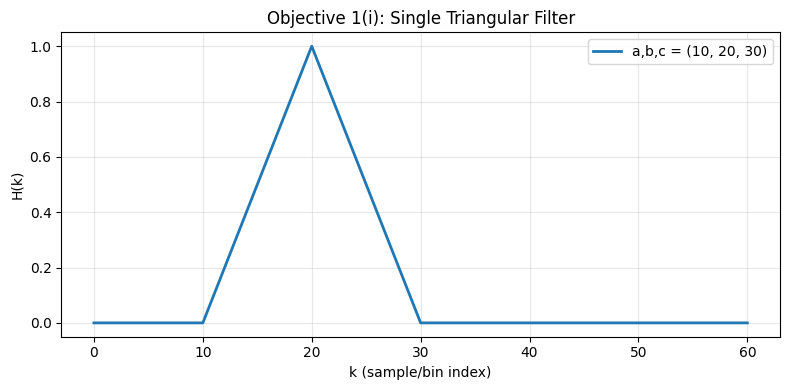

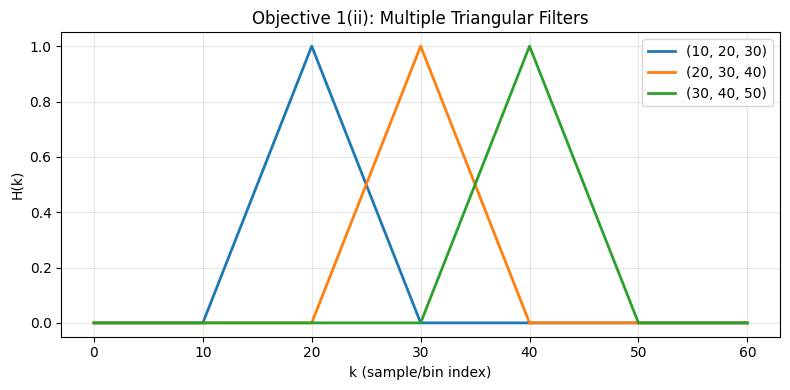

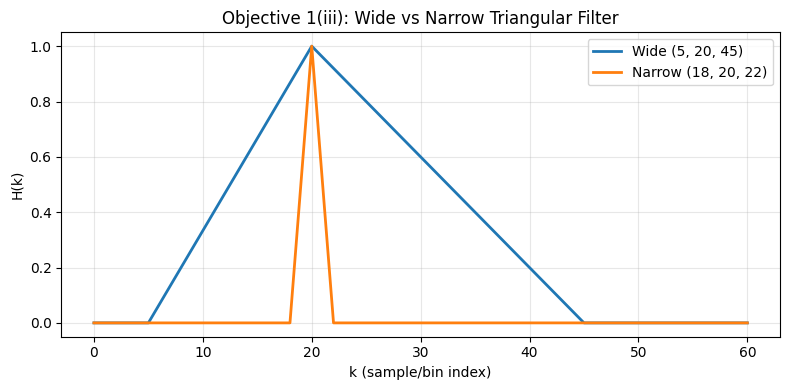

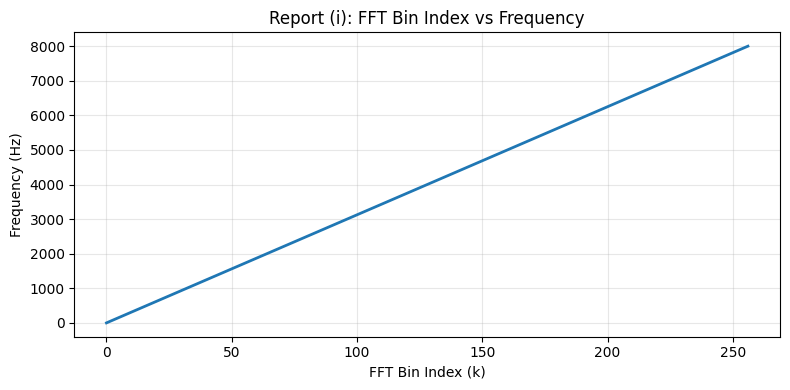

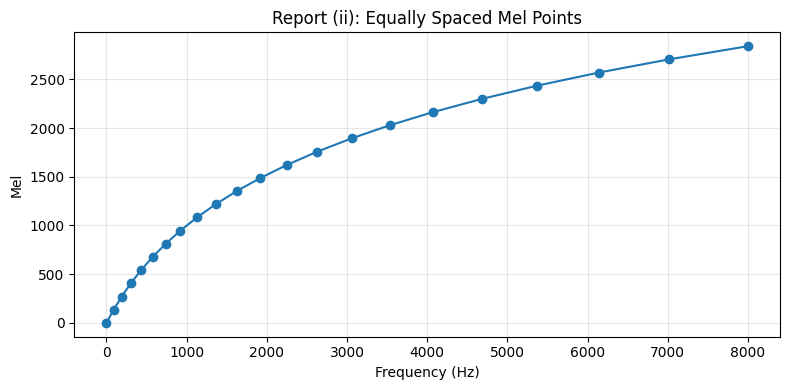

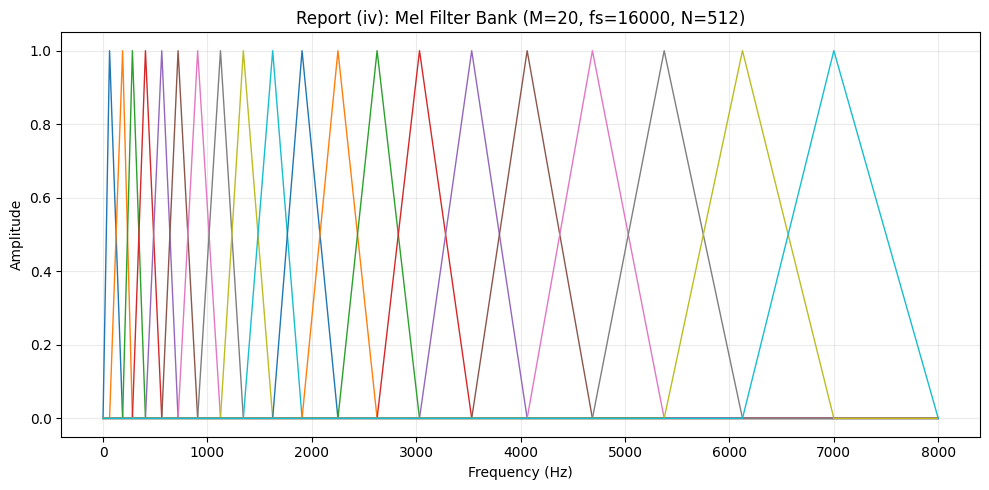

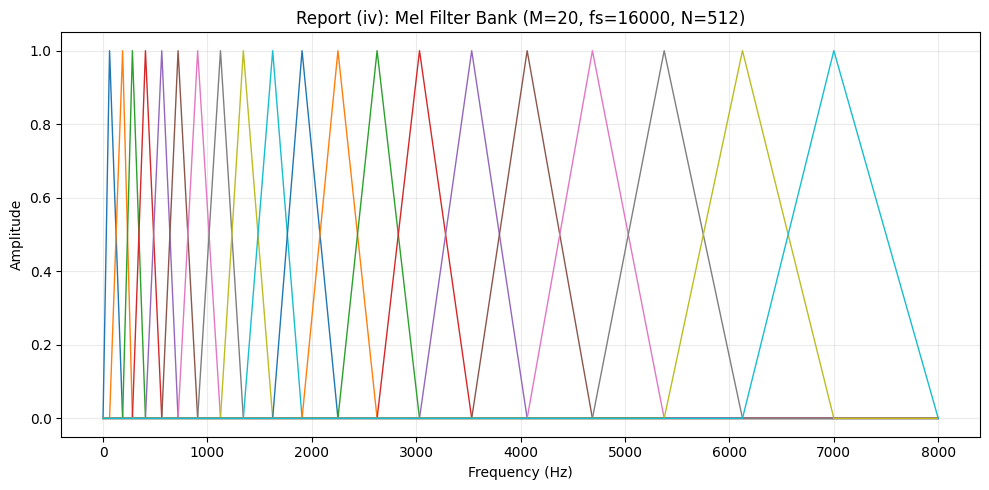

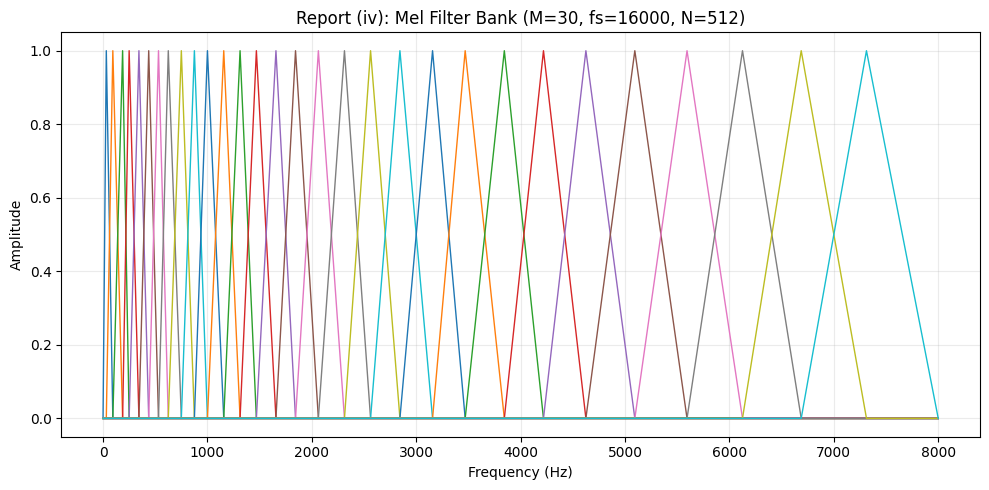

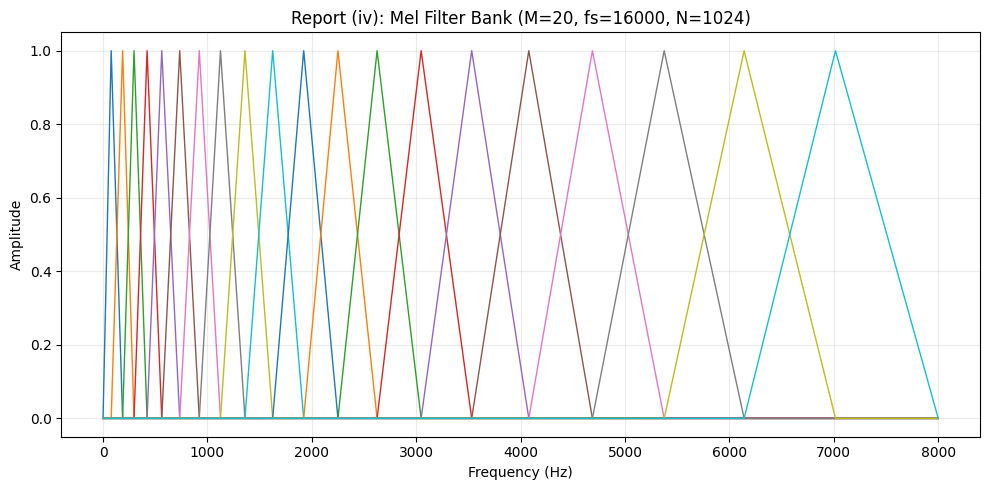

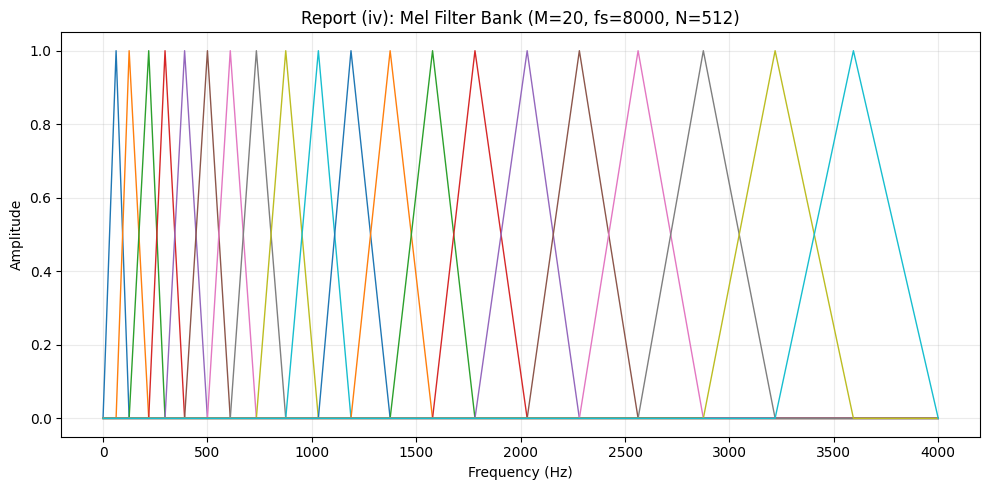

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt


def triangular_filter(k, a, b, c):
    """Return one triangular filter H(k) defined by points (a, b, c)."""
    h = np.zeros_like(k, dtype=float)

    rise = (k >= a) & (k <= b)
    if b != a:
        h[rise] = (k[rise] - a) / (b - a)

    fall = (k >= b) & (k <= c)
    if c != b:
        h[fall] = (c - k[fall]) / (c - b)

    return h


def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)


def mel_to_hz(m):
    return 700 * (10 ** (m / 2595) - 1)


def build_mel_filter_bank(fs=16000, n_fft=512, n_filters=20, fmin=0, fmax=None):
    """Construct Mel filter bank and return all intermediate values used in the report."""
    if fmax is None:
        fmax = fs / 2

    mel_min = hz_to_mel(fmin)
    mel_max = hz_to_mel(fmax)

    mel_points = np.linspace(mel_min, mel_max, n_filters + 2)
    hz_points = mel_to_hz(mel_points)

    bins = np.floor((n_fft + 1) * hz_points / fs).astype(int)

    num_bins_half = n_fft // 2 + 1
    fbank = np.zeros((n_filters, num_bins_half), dtype=float)

    for m in range(1, n_filters + 1):
        left = bins[m - 1]
        center = bins[m]
        right = bins[m + 1]

        if center > left:
            for k in range(left, center + 1):
                if 0 <= k < num_bins_half:
                    fbank[m - 1, k] = (k - left) / (center - left)

        if right > center:
            for k in range(center, right + 1):
                if 0 <= k < num_bins_half:
                    fbank[m - 1, k] = (right - k) / (right - center)

    return {
        "fs": fs,
        "n_fft": n_fft,
        "n_filters": n_filters,
        "fmin": fmin,
        "fmax": fmax,
        "mel_min": mel_min,
        "mel_max": mel_max,
        "mel_points": mel_points,
        "hz_points": hz_points,
        "bins": bins,
        "fbank": fbank,
    }


def plot_objective_1(output_dir):
    k = np.arange(0, 61)

    # (i) Single triangle
    single_points = (10, 20, 30)
    h_single = triangular_filter(k, *single_points)

    plt.figure(figsize=(8, 4))
    plt.plot(k, h_single, linewidth=2, label=f"a,b,c = {single_points}")
    plt.title("Objective 1(i): Single Triangular Filter")
    plt.xlabel("k (sample/bin index)")
    plt.ylabel("H(k)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "obj1_single_triangle.png"), dpi=150)

    # (ii) Multiple triangles
    points_list = [(10, 20, 30), (20, 30, 40), (30, 40, 50)]
    plt.figure(figsize=(8, 4))
    for pts in points_list:
        plt.plot(k, triangular_filter(k, *pts), linewidth=2, label=f"{pts}")
    plt.title("Objective 1(ii): Multiple Triangular Filters")
    plt.xlabel("k (sample/bin index)")
    plt.ylabel("H(k)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "obj1_multiple_triangles.png"), dpi=150)

    # (iii) Wider vs narrower triangle
    wide = (5, 20, 45)
    narrow = (18, 20, 22)
    plt.figure(figsize=(8, 4))
    plt.plot(k, triangular_filter(k, *wide), linewidth=2, label=f"Wide {wide}")
    plt.plot(k, triangular_filter(k, *narrow), linewidth=2, label=f"Narrow {narrow}")
    plt.title("Objective 1(iii): Wide vs Narrow Triangular Filter")
    plt.xlabel("k (sample/bin index)")
    plt.ylabel("H(k)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "obj1_wide_vs_narrow.png"), dpi=150)


def plot_fft_bin_vs_frequency(result, output_dir):
    fs = result["fs"]
    n_fft = result["n_fft"]
    bins = np.arange(0, n_fft // 2 + 1)
    freqs = bins * fs / n_fft

    plt.figure(figsize=(8, 4))
    plt.plot(bins, freqs, linewidth=2)
    plt.title("Report (i): FFT Bin Index vs Frequency")
    plt.xlabel("FFT Bin Index (k)")
    plt.ylabel("Frequency (Hz)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "report_i_fftbin_vs_frequency.png"), dpi=150)


def plot_mel_points(result, output_dir):
    hz_points = result["hz_points"]
    mel_points = result["mel_points"]

    plt.figure(figsize=(8, 4))
    plt.plot(hz_points, mel_points, marker="o", linewidth=1.5)
    plt.title("Report (ii): Equally Spaced Mel Points")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Mel")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "report_ii_mel_points.png"), dpi=150)


def print_triangular_points(result):
    bins = result["bins"]
    hz_points = result["hz_points"]
    n_filters = result["n_filters"]

    print("\nReport (iii): Triangular filter points (a, b, c) for each Mel filter")
    print("Filter\ta(bin)\tb(bin)\tc(bin)\ta(Hz)\tb(Hz)\tc(Hz)")
    for m in range(1, n_filters + 1):
        a_bin, b_bin, c_bin = bins[m - 1], bins[m], bins[m + 1]
        a_hz, b_hz, c_hz = hz_points[m - 1], hz_points[m], hz_points[m + 1]
        print(f"{m:02d}\t{a_bin:5d}\t{b_bin:5d}\t{c_bin:5d}\t{a_hz:7.2f}\t{b_hz:7.2f}\t{c_hz:7.2f}")


def plot_mel_filter_bank(result, output_dir, filename):
    fbank = result["fbank"]
    fs = result["fs"]
    n_fft = result["n_fft"]

    freq_axis = np.arange(0, n_fft // 2 + 1) * fs / n_fft

    plt.figure(figsize=(10, 5))
    for m in range(fbank.shape[0]):
        plt.plot(freq_axis, fbank[m], linewidth=1)

    plt.title(
        f"Report (iv): Mel Filter Bank (M={result['n_filters']}, fs={fs}, N={n_fft})"
    )
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, filename), dpi=150)


def report_parameter_change(output_dir):
    """Report (v): Change parameters and visualize the impact."""
    # Baseline required by assignment
    base = build_mel_filter_bank(fs=16000, n_fft=512, n_filters=20)
    plot_mel_filter_bank(base, output_dir, "report_iv_mel_filter_bank_default.png")

    # Case A: more filters
    case_a = build_mel_filter_bank(fs=16000, n_fft=512, n_filters=30)
    plot_mel_filter_bank(case_a, output_dir, "report_v_caseA_more_filters_M30.png")

    # Case B: larger FFT size
    case_b = build_mel_filter_bank(fs=16000, n_fft=1024, n_filters=20)
    plot_mel_filter_bank(case_b, output_dir, "report_v_caseB_larger_fft_N1024.png")

    # Case C: smaller sampling rate
    case_c = build_mel_filter_bank(fs=8000, n_fft=512, n_filters=20)
    plot_mel_filter_bank(case_c, output_dir, "report_v_caseC_fs8000.png")

    print("\nReport (v): Parameter-change cases generated:")
    print("1) M=30, fs=16000, N=512")
    print("2) M=20, fs=16000, N=1024")
    print("3) M=20, fs=8000,  N=512")


def main():
    output_dir = os.path.join("LAB5", "outputs")
    os.makedirs(output_dir, exist_ok=True)

    # Objective 1
    plot_objective_1(output_dir)

    # Objective 2 with required parameters
    result = build_mel_filter_bank(fs=16000, n_fft=512, n_filters=20)

    # Report requirements (i) to (iv)
    plot_fft_bin_vs_frequency(result, output_dir)
    plot_mel_points(result, output_dir)
    print_triangular_points(result)
    plot_mel_filter_bank(result, output_dir, "report_iv_mel_filter_bank_default.png")

    # Report requirement (v)
    report_parameter_change(output_dir)

    print("\nAll required plots saved in: LAB5/outputs")
    print("Generated files:")
    for name in sorted(os.listdir(output_dir)):
        print("-", name)

    plt.show()


if __name__ == "__main__":
    main()
